In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mdverse_entity_norm.scripts.normalize_simulation_time import (
    normalize_simulation_time,
)

In [104]:
UNITS_TO_NS = {
    "fs": 1e-6,
    "ps": 1e-3,
    "ns": 1,
    "μs": 1e3,
    "us": 1e3,
    "microseconds": 1e3,
    "microsecond": 1e3,
    "ms": 1e6,
    "milliseconds": 1e6,
    "s": 1e9,
    "seconds": 1e9,
    "ks": 1e12,
}

pattern = re.compile(
    r"([0-9]+)(\.?[0-9]+)? *(fs|ps|ns|μs|us|ms|ks|s)",
    re.IGNORECASE,
)

In [3]:
df = pd.read_csv("../data/entities.tsv", sep="\t")
df_stime = df[df["category"] == "STIME"].copy()
df_stime

,entity,category,json_file
15,200ns,STIME,zenodo_34415.json
16,100ns,STIME,zenodo_34415.json
18,1 ns,STIME,figshare_8046437.json
38,500ns,STIME,zenodo_1009027.json
42,700ns,STIME,zenodo_1009027.json
...,...,...,...
1568,100 ns,STIME,figshare_22182562.json
1594,300 ns,STIME,zenodo_6144286.json
1641,4-microsecond,STIME,zenodo_2645909.json
1681,100 ns,STIME,zenodo_573274.json


In [ ]:
MODEL_NAME = "deepseek/deepseek-v4-pro"
PROMPT_PATH = Path("../data/llm_prompt.txt")


def normalize_row(raw_time):
    try:
        result = normalize_simulation_time(
            raw_simulation_time=str(raw_time),
            model_name=MODEL_NAME,
            prompt_file_path=PROMPT_PATH,
        )
        if result and result[0]:
            return result[0]
    except Exception as e:
        print(f"Erreur pour {raw_time}: {e}")
    return None


df_stime["normalized_time"] = df_stime["entity"].apply(normalize_row)
df_stime.head()

In [ ]:
valid_ns_llm = []

for row in df_stime.iterrows():
    data = json.loads(row["normalized_time"])

    output = data["output"][0]
    has_value = "value" in output and output["value"] is not None
    has_unit = "unit" in output and output["unit"] is not None

    if not has_value or not has_unit:
        print(f"Excluded (missing field): {data['input']}")
        continue

    unit = output["unit"].strip().lower()
    if unit not in UNITS_TO_NS:
        print(f"Excluded (not a time unit): {data['input']}")
        continue

    value_ns = float(output["value"]) * UNITS_TO_NS[unit]
    valid_ns_llm.append(value_ns)
    print(f"Kept: {data['input']}  ->  {output['value']} {unit}  =  {value_ns} ns")

print(f"\nTotal kept (LLM): {len(valid_ns_llm)} values")

Kept: 200ns  ->  200.0 ns  =  200.0 ns
Kept: 100ns  ->  100.0 ns  =  100.0 ns
Kept: 1 ns  ->  1.0 ns  =  1.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 700ns  ->  700.0 ns  =  700.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 700ns  ->  700.0 ns  =  700.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 1069 ns  ->  1069.0 ns  =  1069.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 40ns  ->  40.0 ns  =  40.0 ns
Kept: 110 ns  ->  110.0 ns  =  110.0 ns
Kept: 11 ns  ->  11.0 ns  =  11.0 ns
Kept: 2 microseconds  ->  2.0 μs  =  2000.0 ns
Kept: 100–200 ns  ->  100.0 ns  =  100.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 380 ns  ->  380.0 ns  =  380.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 200ns  ->  200.0 ns  =  200.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 200ns  ->  200.0 ns  =  200.0 ns
Kept: 10 mic

In [122]:
valid_ns_reg = []

for _, row in df_stime.iterrows():
    entity = str(row["entity"])
    match = pattern.search(entity)

    if not match:
        print(f"Excluded (no match): {entity}")
        continue

    value = float(match.group(1) + (match.group(2) or ""))
    unit = match.group(3).strip().lower()

    if unit not in UNITS_TO_NS:
        print(f"Excluded (unknown unit): {entity}")
        continue

    value_ns = value * UNITS_TO_NS[unit]
    valid_ns_reg.append(value_ns)
    print(f"Kept: {entity}  ->  {value} {unit}  =  {value_ns} ns")

print(f"\nTotal kept (regex): {len(valid_ns_reg)} values")

Kept: 200ns  ->  200.0 ns  =  200.0 ns
Kept: 100ns  ->  100.0 ns  =  100.0 ns
Kept: 1 ns  ->  1.0 ns  =  1.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 700ns  ->  700.0 ns  =  700.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 700ns  ->  700.0 ns  =  700.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 500ns  ->  500.0 ns  =  500.0 ns
Kept: 1069 ns  ->  1069.0 ns  =  1069.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 40ns  ->  40.0 ns  =  40.0 ns
Kept: 110 ns  ->  110.0 ns  =  110.0 ns
Kept: 11 ns  ->  11.0 ns  =  11.0 ns
Excluded (no match): 2 microseconds
Kept: 100–200 ns  ->  200.0 ns  =  200.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 380 ns  ->  380.0 ns  =  380.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 200ns  ->  200.0 ns  =  200.0 ns
Kept: 200 ns  ->  200.0 ns  =  200.0 ns
Kept: 200ns  ->  200.0 ns  =  200.0 ns
Excluded (no match): 10

In [117]:
print(f"LLM  : {len(valid_ns_llm)} values")
print(f"Regex: {len(valid_ns_reg)} values")

LLM  : 112 values
Regex: 88 values


In [119]:
print(len(valid_ns_llm), len(valid_ns_reg))

112 88


In [121]:
valid_ns_reg

[200.0,
 100.0,
 1.0,
 500.0,
 700.0,
 500.0,
 700.0,
 500.0,
 500.0,
 500.0,
 500.0,
 500.0,
 1069.0,
 200.0,
 40.0,
 110.0,
 11.0,
 200.0,
 200.0,
 380.0,
 200.0,
 200.0,
 200.0,
 200.0,
 100.0,
 50.0,
 1000.0,
 100.0,
 100.0,
 50.0,
 10.0,
 500.0,
 500.0,
 500.0,
 500.0,
 500.0,
 550.0,
 550.0,
 125.0,
 500.0,
 80.0,
 500.0,
 250.0,
 3000.0,
 250.0,
 12000.0,
 250.0,
 200.0,
 500.0,
 800.0,
 200.0,
 200.0,
 100.0,
 190.0,
 1.0,
 60.0,
 0.0,
 4200.0,
 100.0,
 500.0,
 500.0,
 1000.0,
 1500.0,
 500.0,
 1000.0,
 1500.0,
 450.0,
 200.0,
 300.0,
 120.0,
 100.0,
 5000.0,
 20.0,
 0.5,
 0.5,
 5000.0,
 500.0,
 1500.0,
 150.0,
 1500.0,
 500.0,
 370.0,
 27.0,
 50.0,
 100.0,
 300.0,
 100.0,
 200.0]

In [120]:
valid_ns_llm

[200.0,
 100.0,
 1.0,
 500.0,
 700.0,
 500.0,
 700.0,
 500.0,
 500.0,
 500.0,
 500.0,
 500.0,
 1069.0,
 200.0,
 40.0,
 110.0,
 11.0,
 2000.0,
 100.0,
 200.0,
 200.0,
 380.0,
 200.0,
 200.0,
 200.0,
 200.0,
 10000.0,
 1000.0,
 6000.0,
 1000.0,
 100.0,
 50.0,
 1000.0,
 1000.0,
 1500.0,
 100.0,
 100.0,
 50.0,
 87000.0,
 10.0,
 500.0,
 500.0,
 500.0,
 500.0,
 500.0,
 550.0,
 550.0,
 125.0,
 500.0,
 80.0,
 500.0,
 250.0,
 3000.0,
 250.0,
 12000.0,
 250.0,
 200.0,
 500.0,
 800.0,
 200.0,
 200.0,
 100.0,
 190.0,
 1000.0,
 1.6,
 6000.0,
 60.0,
 1000.0,
 500.0,
 4200.0,
 100.0,
 500.0,
 2000.0,
 8000.0,
 5000.0,
 500.0,
 1000.0,
 1500.0,
 500.0,
 1000.0,
 1500.0,
 1000.0,
 450.0,
 100.0,
 200.0,
 200.0,
 300.0,
 120.0,
 100.0,
 5000.0,
 20.0,
 1000.0,
 0.5,
 0.5,
 5000.0,
 500.0,
 1500.0,
 150.0,
 300.0,
 1000.0,
 1500.0,
 500.0,
 370.0,
 100.0,
 100.0,
 27.0,
 50.0,
 100.0,
 300.0,
 4000.0,
 100.0,
 200.0]

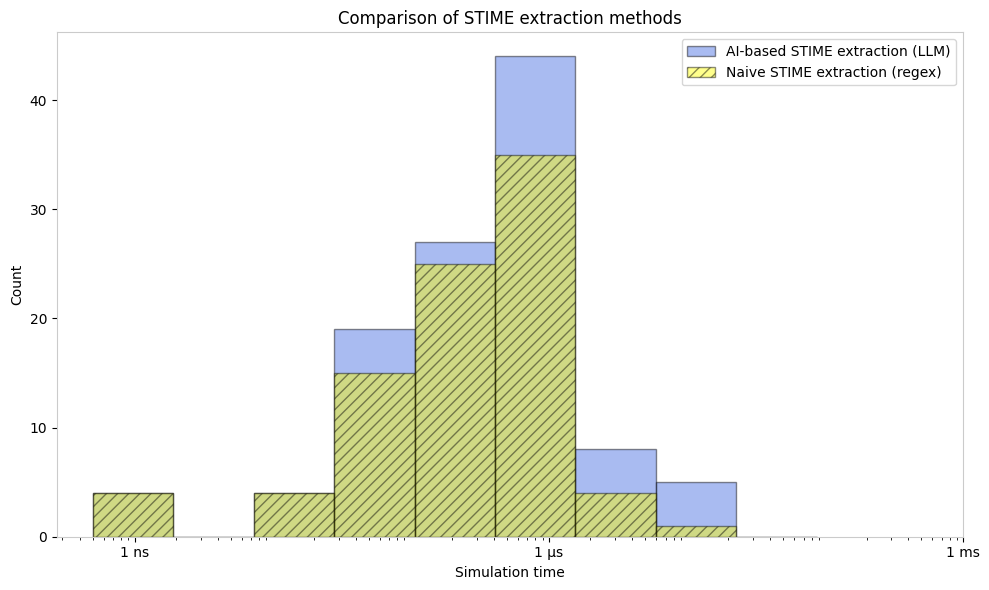

In [123]:
global_min = min(min(valid_ns_llm), min(valid_ns_reg))
global_max = max(max(valid_ns_llm), max(valid_ns_reg))
shared_bins = np.logspace(np.log10(global_min), np.log10(global_max), 10)

x_ticks = [1e0, 1e3, 1e6]
x_labels = ["1 ns", "1 μs", "1 ms"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    valid_ns_llm,
    bins=shared_bins,
    color="royalblue",
    edgecolor="black",
    alpha=0.45,
    label="AI-based STIME extraction (LLM)",
)
ax.hist(
    valid_ns_reg,
    bins=shared_bins,
    color="yellow",
    edgecolor="black",
    hatch="///",
    alpha=0.45,
    label="Naive STIME extraction (regex)",
)
ax.set_xscale("log")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Simulation time")
ax.set_ylabel("Count")
ax.set_title("Comparison of STIME extraction methods")
ax.legend()
plt.tight_layout()
plt.savefig("stime_comparison.png")
plt.show()

In [ ]:
rows = []

for _, row in df_stime.iterrows():
    # With Regex
    reg_value, reg_unit = None, None
    match = pattern.search(str(row["entity"]))
    if match:
        reg_value = float(match.group(1) + (match.group(2) or ""))
        reg_unit = match.group(3).strip().lower()
        if reg_unit not in UNITS_TO_NS:
            reg_value, reg_unit = None, None

    # With LLM
    llm_outputs = []

    outputs = json.loads(row["normalized_time"])["output"]
    for output in outputs:
        if output.get("value") is not None and output.get("unit") is not None:
            unit = output["unit"].strip().lower()
            if unit in UNITS_TO_NS:
                llm_outputs.append((float(output["value"]), unit))
    if not llm_outputs:
        llm_outputs = [(None, None)]

    for llm_value, llm_unit in llm_outputs:
        rows.append(
            {
                "STIME": str(row["entity"]),
                "value_by_regex": reg_value if reg_value is not None else "None",
                "unit_by_regex": reg_unit if reg_unit is not None else "None",
                "value_by_llm": llm_value if llm_value is not None else "None",
                "unit_by_llm": llm_unit if llm_unit is not None else "None",
            }
        )

df_comparison = pd.DataFrame(rows)
df_comparison.to_csv("../results/stime_comparison.tsv", sep="\t", index=False)
print("File saved in ../results/stime_comparison.tsv ")
df_comparison

,STIME,value_by_regex,unit_by_regex,value_by_llm,unit_by_llm
0,200ns,200.0,ns,200.0,ns
1,100ns,100.0,ns,100.0,ns
2,1 ns,1.0,ns,1.0,ns
3,500ns,500.0,ns,500.0,ns
4,700ns,700.0,ns,700.0,ns
...,...,...,...,...,...
112,100 ns,100.0,ns,100.0,ns
113,300 ns,300.0,ns,300.0,ns
114,4-microsecond,None,None,4.0,μs
115,100 ns,100.0,ns,100.0,ns
